In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path

root_path = Path("..")
fine_tuning_path = root_path / "fine_tuning"

Train/val/test split on seed titles (stratified by ONET code)

In [3]:
full_jitter_titles_path = root_path / 'synthetic_data' / 'data' / 'jittered_titles.csv'

dataset_dir_path = fine_tuning_path / 'data' / 'datasets'
if not dataset_dir_path.is_dir():
    dataset_dir_path.mkdir(parents=True)
all_dataset_paths = [
    dataset_dir_path / 'train_ds.csv',
    dataset_dir_path / 'val_ds.csv',
    dataset_dir_path / 'test_ds.csv'
]

if all([p.is_file() for p in all_dataset_paths]):
    train_df = pd.read_csv(all_dataset_paths[0])
    val_df = pd.read_csv(all_dataset_paths[1])
    test_df = pd.read_csv(all_dataset_paths[2])

else:
    jittered_titles_df = pd.read_csv(full_jitter_titles_path)

    unique_onets = jittered_titles_df['onet_code'].unique()

    #Proportion of ONET coverage in each split
    val_p = 0.6
    test_p = 1.0

    val_mask = np.random.uniform(size=len(unique_onets)) < val_p
    test_mask = np.random.uniform(size=len(unique_onets)) < test_p

    val_clean_titles = []
    test_clean_titles = []

    for i, onet in enumerate(unique_onets):
        onet_clean_titles = jittered_titles_df[jittered_titles_df['onet_code'] == onet]['seed_title'].unique()
        if len(onet_clean_titles) < 4:
            print(f'onet {onet} has {len(onet_clean_titles)} seed titles')
        else:
            to_split_off = np.random.choice(onet_clean_titles, size=2, replace=False)
            if val_mask[i]:
                val_clean_titles.append(to_split_off[0])
            if test_mask[i]:
                test_clean_titles.append(to_split_off[1])



    val_df = jittered_titles_df[jittered_titles_df['seed_title'].isin(val_clean_titles)]
    test_df = jittered_titles_df[jittered_titles_df['seed_title'].isin(test_clean_titles)]
    train_df = jittered_titles_df[(~jittered_titles_df['seed_title'].isin(test_clean_titles)) & (~jittered_titles_df['seed_title'].isin(val_clean_titles))]

    train_df.to_csv(all_dataset_paths[0], index=False)
    val_df.to_csv(all_dataset_paths[1], index=False)
    test_df.to_csv(all_dataset_paths[2], index=False)

print(f'Train size: {len(train_df)}')
print(f'Val size: {len(val_df)}')
print(f'Test size: {len(test_df)}')

Train size: 19755
Val size: 4950
Test size: 4370


TODO: Take a look at the seed titles with abbreviations in parentheses. How do we want to handle these when constructing training examples?<br>
What ramifications might that have for how the model deals with abbreviations? Brainstorm and experiment with a few different approaches

In [4]:
import re

# This approach just takes the longer of the two titles always
def split_title(job_title):
    m = re.search(r'\(.*\)$', job_title)
    if not m:
        return None
    abbreviated_title = m.group()[1:-1]
    un_abbreviated_title = job_title[:m.span()[0] - 1]
    return abbreviated_title, un_abbreviated_title

def get_clean_title(title):
    split_title_result = split_title(title)
    if split_title_result:
        return split_title_result[np.argmax([len(t) for t in split_title_result])]
    return title

This is formulated such that:
<ul>
<li>Anchor: Jittered Title
<li>Positive: True Seed Title
<li>Negative: Negative Seed Title
</ul><br>
I think it would be equally valid to do this the other way (anchor is a seed title, positive & negative are jittered titles)


TODO: This will be our default base model; feel free to experiment with others (larger models, newer architectures etc.)!

In [5]:
from sentence_transformers import SentenceTransformer

base_model_name = 'sentence-transformers/all-MiniLM-L6-v2'

base_model = SentenceTransformer(base_model_name)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


This is frankly a pretty overly complicated way to set up the dataset, as a randomized generator. This was the easiest way to get it to play nicely with the new SentenceTransformerTrainer<br>
TODO: experiment with different loss functions and different ways of constructing training examples

In [6]:
from datasets import IterableDataset, Features, Value

def generate_training_examples(ds, take_longest_variant=True, infinite=True):
    rng = np.random.default_rng()

    if take_longest_variant:
        ds['seed_title'] = ds['seed_title'].apply(get_clean_title)

    ds = ds.reset_index(drop=True)
    anchors = ds['jittered_title'].to_numpy()
    positives = ds['seed_title'].to_numpy()
    seed_titles = ds['seed_title'].unique()

    negative_indices_list = []
    for positive in positives:
        negative_indices_list.append(
            np.arange(len(seed_titles))[seed_titles != positive]
        )

    indices = list(range(len(anchors)))
    while infinite:
        rng.shuffle(indices)

        for idx in indices:
            negative_indices = negative_indices_list[idx]
            negative_idx = rng.choice(negative_indices)
            yield {
                'anchor': anchors[idx],
                'positive': positives[idx],
                'negative': seed_titles[negative_idx]
            }

# Create the IterableDataset
train_ds = IterableDataset.from_generator(
    generate_training_examples,
    gen_kwargs={'ds': train_df, 'take_longest_variant': True, 'infinite': True},
    features=Features(
        {
            'anchor': Value('string'),
            'positive': Value('string'),
            'negative': Value('string'),
        }
    ),
).with_format(None) 


In [7]:
from datasets import Dataset

def generate_val_examples(ds, take_longest_variant=True, negatives_per_positive=5):
    rng = np.random.default_rng()

    if take_longest_variant:
        ds['seed_title'] = ds['seed_title'].apply(get_clean_title)

    ds = ds.reset_index(drop=True)
    anchors = ds['jittered_title'].to_numpy()
    positives = ds['seed_title'].to_numpy()
    seed_titles = ds['seed_title'].unique()

    examples = []
    for anchor, positive in zip(anchors, positives):
        negatives = rng.choice(seed_titles[seed_titles != positive], size=negatives_per_positive, replace=False)
        for negative in negatives:
            examples.append({
                'anchor': anchor,
                'positive': positive,
                'negative': negative
            })

    return examples

val_ds = Dataset.from_list(generate_val_examples(val_df, take_longest_variant=True, negatives_per_positive=5)).with_format(None)

In [8]:
# example_triplet = next(iter(train_ds))

# print('Example Triplet:')
# print('Anchor:', example_triplet['anchor']) 
# print('Positive:', example_triplet['positive'])   
# print('Negative:', example_triplet['negative'])

In [9]:
from sentence_transformers import losses

train_loss = losses.TripletLoss(model=base_model, triplet_margin=0.3)

In [10]:
num_epochs = 5
train_batch_size = 192
val_batch_size = 192

evals_per_epoch = 4

In [11]:
from datetime import datetime
# model_save_path = os.path.join(fine_tuning_path, 'data', 'trained_models')
model_save_path = fine_tuning_path / 'data' / 'trained_models'
model_name = f'{base_model_name.replace("/", "-")}_triplet_{datetime.now().strftime("%Y-%m-%d_%H-%M-%S")}'

TODO: Use tensorboard to monitor the training

In [12]:
from sentence_transformers import SentenceTransformerTrainingArguments

steps_per_epoch = len(train_df) // train_batch_size
steps_per_eval = steps_per_epoch // evals_per_epoch

train_args = SentenceTransformerTrainingArguments(
    # Required parameter:
    output_dir=str(model_save_path),
    # Optional training parameters:
    max_steps = steps_per_epoch * num_epochs,
    num_train_epochs=num_epochs,
    warmup_ratio=0.1,
    per_device_train_batch_size=train_batch_size,
    per_device_eval_batch_size=val_batch_size,
    # Optional tracking/debugging parameters:
    eval_strategy="steps",
    eval_steps=steps_per_eval,
    save_strategy="steps",
    save_steps=steps_per_eval,
    save_total_limit=2,
    logging_steps=steps_per_eval,
    report_to='tensorboard',
    run_name=model_name,  # Will be used in W&B if `wandb` is installed
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


TODO: Brainstorm some other relevant metrics to track, and add these to tensorboard (I think this is most easily done as an evaluator, but there may be other approaches, check the docs!)

Step,Training Loss,Validation Loss,Job-title-triplet-eval Cosine Accuracy,Job-title-ir-eval Cosine Accuracy@1,Job-title-ir-eval Cosine Accuracy@3,Job-title-ir-eval Cosine Accuracy@5,Job-title-ir-eval Cosine Accuracy@10,Job-title-ir-eval Cosine Precision@1,Job-title-ir-eval Cosine Precision@3,Job-title-ir-eval Cosine Precision@5,Job-title-ir-eval Cosine Precision@10,Job-title-ir-eval Cosine Recall@1,Job-title-ir-eval Cosine Recall@3,Job-title-ir-eval Cosine Recall@5,Job-title-ir-eval Cosine Recall@10,Job-title-ir-eval Cosine Ndcg@10,Job-title-ir-eval Cosine Mrr@10,Job-title-ir-eval Cosine Map@100,Sequential Score
25,0.079766,0.073121,0.084687,0.001010,0.001010,0.001010,0.001212,0.001010,0.000337,0.000202,0.000121,0.001010,0.001010,0.001010,0.001212,0.001074,0.001035,0.001144,0.001074
50,0.081565,0.071378,0.080202,0.000000,0.000000,0.000202,0.000202,0.000000,0.000000,0.000040,0.000020,0.000000,0.000000,0.000202,0.000202,0.000087,0.000051,0.000099,0.000087
75,0.074607,0.067280,0.072485,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000063,0.000000
100,0.076381,0.065763,0.069616,0.000000,0.000000,0.000000,0.000202,0.000000,0.000000,0.000000,0.000020,0.000000,0.000000,0.000000,0.000202,0.000064,0.000025,0.000109,0.000064
125,0.071045,0.062620,0.066384,0.000404,0.000606,0.000808,0.001010,0.000404,0.000202,0.000162,0.000101,0.000404,0.000606,0.000808,0.001010,0.000679,0.000578,0.000632,0.000679
150,0.065643,0.059845,0.063071,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000052,0.000000
175,0.065396,0.059356,0.058020,0.001010,0.001010,0.001010,0.001212,0.001010,0.000337,0.000202,0.000121,0.001010,0.001010,0.001010,0.001212,0.001074,0.001035,0.001087,0.001074
200,0.063925,0.057169,0.057576,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000036,0.000000
225,0.063699,0.055853,0.057172,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000027,0.000000
250,0.061299,0.052673,0.052485,0.000000,0.000000,0.000000,0.000202,0.000000,0.000000,0.000000,0.000020,0.000000,0.000000,0.000000,0.000202,0.000072,0.000034,0.000045,0.000072


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

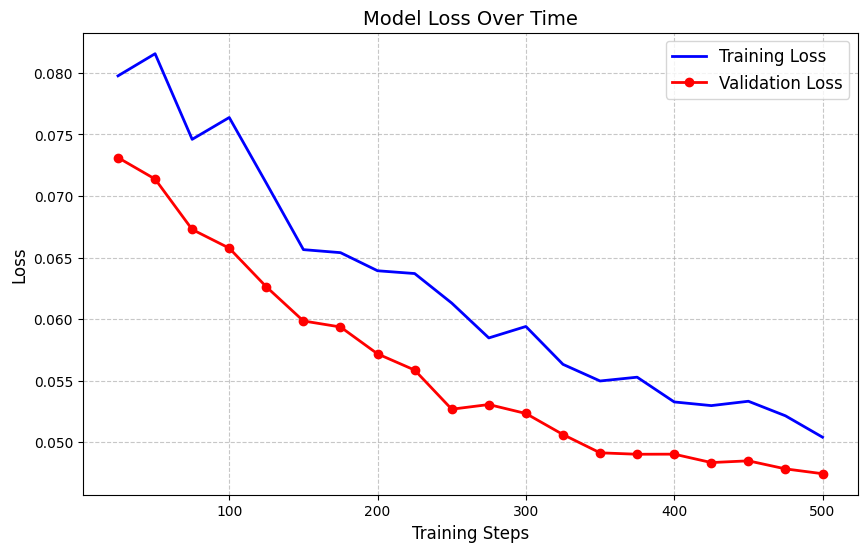

In [15]:
from sentence_transformers import SentenceTransformerTrainer
from sentence_transformers.evaluation import (
    TripletEvaluator, 
    InformationRetrievalEvaluator, 
    SequentialEvaluator
)

triplet_evaluator = TripletEvaluator(
    anchors=val_ds["anchor"],
    positives=val_ds["positive"],
    negatives=val_ds["negative"],
    name="job-title-triplet-eval"
)

queries = {}
corpus = {}
relevant_docs = {}

unique_seed_titles = val_df['seed_title'].unique()
for i, title in enumerate(unique_seed_titles):
    corpus[str(i)] = title


title_to_doc_id = {title: str(i) for i, title in enumerate(unique_seed_titles)}
for i, row in val_df.iterrows():
    query_id = f"q_{i}"
    queries[query_id] = row['jittered_title']
    relevant_docs[query_id] = {title_to_doc_id[row['seed_title']]}

ir_evaluator = InformationRetrievalEvaluator(
    queries=queries,
    corpus=corpus,
    relevant_docs=relevant_docs,
    name="job-title-ir-eval"
)


seq_evaluator = SequentialEvaluator([triplet_evaluator, ir_evaluator])
trainer = SentenceTransformerTrainer(
    model=base_model,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    args=train_args,
    loss=train_loss,
    evaluator=seq_evaluator, 
)

trainer.train()
history = trainer.state.log_history


train_steps = [log["step"] for log in history if "loss" in log]
train_losses = [log["loss"] for log in history if "loss" in log]
eval_steps = [log["step"] for log in history if "eval_loss" in log]
eval_losses = [log["eval_loss"] for log in history if "eval_loss" in log]
plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_losses, label="Training Loss", color="blue", linewidth=2)


if eval_losses:
    plt.plot(eval_steps, eval_losses, label="Validation Loss", color="red", marker="o", linewidth=2)

plt.xlabel("Training Steps", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Model Loss Over Time", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()